EDA

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Read Dataset
df= pd.read_csv("student_performance_dataset.csv")

In [4]:
# View Dataset
df.head()
df.tail()

,student_name,city,study_hours,social_media_hours,revision_hour,cgpa,result
155,Komal Yadav,Kochi,6.3,3.3,1.3,6.86,Pass
156,Myra Chopra,Toronto,5.1,5.3,0.3,5.18,Fail
157,Aarav Chatterjee,Lucknow,9.5,6.1,4.6,8.73,Pass
158,John Yadav,Hyderabad,1.7,4.3,1.4,4.43,Fail
159,Om Kumar,Nagpur,8.7,0.3,0.1,8.99,Pass


In [5]:
# Shape
df.shape

(160, 7)

In [6]:
# Column Names
df.columns

Index(['student_name', 'city', 'study_hours', 'social_media_hours',
       'revision_hour', 'cgpa', 'result'],
      dtype='str')

In [8]:
# Datatype
df.dtypes
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 160 entries, 0 to 159
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   student_name        160 non-null    str    
 1   city                156 non-null    str    
 2   study_hours         158 non-null    float64
 3   social_media_hours  158 non-null    float64
 4   revision_hour       154 non-null    float64
 5   cgpa                155 non-null    float64
 6   result              157 non-null    str    
dtypes: float64(4), str(3)
memory usage: 8.9 KB


In [9]:
# Statistical Summary 
df.describe()

,study_hours,social_media_hours,revision_hour,cgpa
count,158.000000,158.000000,154.000000,155.000000
mean,5.218987,4.043671,2.847403,6.843419
std,2.813302,2.326651,1.673992,1.661599
min,0.600000,0.100000,0.100000,3.220000
25%,2.700000,1.925000,1.600000,5.385000
50%,5.200000,4.050000,2.700000,6.740000
75%,7.675000,6.075000,4.100000,8.075000
max,10.000000,7.900000,6.000000,10.000000


In [10]:
# Step 8: Missing Values
df.isnull().sum()

student_name          0
city                  4
study_hours           2
social_media_hours    2
revision_hour         6
cgpa                  5
result                3
dtype: int64

In [11]:
# Fill missing value 
df.fillna(df.median(numeric_only=True), inplace=True)


,student_name,city,study_hours,social_media_hours,revision_hour,cgpa,result
0,Myra Verma,Jaipur,2.8,1.1,0.6,5.75,Pass
1,Ava Yadav,Mumbai,0.8,1.7,3.0,4.42,Pass
2,Isabella Tiwari,Ahmedabad,4.8,2.2,5.2,8.34,Pass
3,Swati Menon,Jaipur,2.0,7.7,2.0,3.22,Pass
4,Raj Anderson,Jaipur,8.2,5.8,3.2,8.69,Pass
...,...,...,...,...,...,...,...
155,Komal Yadav,Kochi,6.3,3.3,1.3,6.86,Pass
156,Myra Chopra,Toronto,5.1,5.3,0.3,5.18,Fail
157,Aarav Chatterjee,Lucknow,9.5,6.1,4.6,8.73,Pass
158,John Yadav,Hyderabad,1.7,4.3,1.4,4.43,Fail


In [12]:
df.isnull().sum()

student_name          0
city                  4
study_hours           0
social_media_hours    0
revision_hour         0
cgpa                  0
result                3
dtype: int64

In [15]:
df["city"] = df["city"].fillna(df["city"].mode()[0])
df["result"] = df["result"].fillna(df["result"].mode()[0])

In [17]:
# Unique Values
df["city"].unique()
df["city"].value_counts()

city
Ahmedabad     19
Jaipur        12
Kochi         12
Lucknow       12
Surat         10
Indore        10
Bhopal         9
Toronto        8
Mumbai         7
Pune           7
Nagpur         7
Delhi          7
Sydney         6
London         6
New York       6
Chennai        6
Bangalore      5
Chandigarh     4
Hyderabad      4
Kolkata        3
Name: count, dtype: int64

(array([18., 15., 23.,  9., 18.,  9., 16., 20., 18., 14.]),
 array([ 0.6 ,  1.54,  2.48,  3.42,  4.36,  5.3 ,  6.24,  7.18,  8.12,
         9.06, 10.  ]),
 <BarContainer object of 10 artists>)

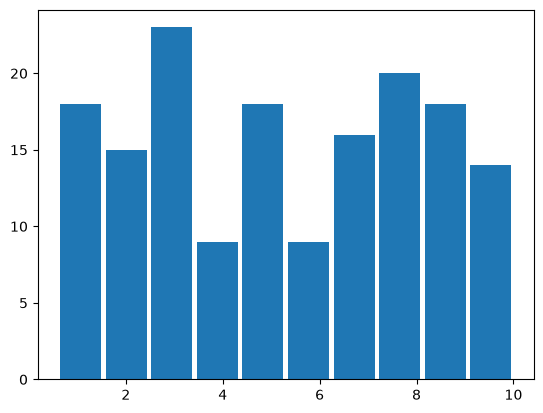

In [21]:
# Histogram
plt.hist(df["study_hours"],rwidth=0.9)

<Axes: xlabel='study_hours'>

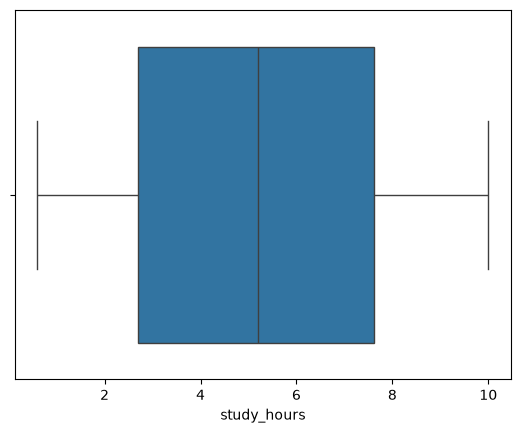

In [22]:
# Boxplot :- detect outliers
sns.boxplot(x=df["study_hours"])

<Axes: >

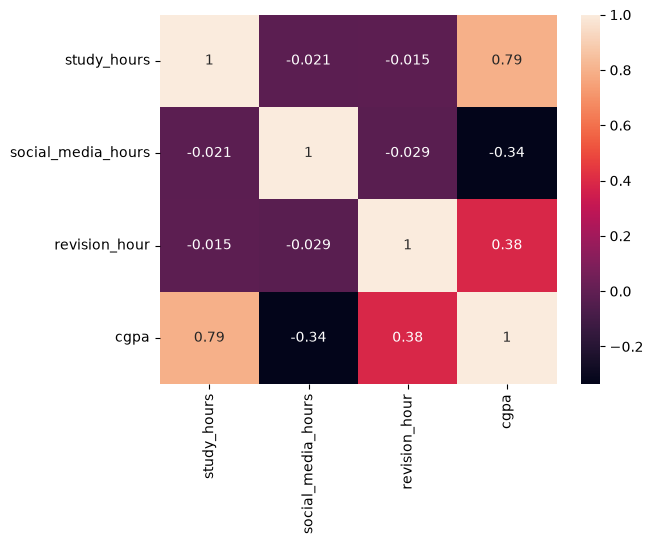

In [23]:
# Correlation
corr = df.corr(numeric_only = True)
sns.heatmap(corr, annot=True)

Feature Engineering

In [24]:
# Encode Categorical Columns
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["result"] = le.fit_transform(df["result"])

In [25]:
df

,student_name,city,study_hours,social_media_hours,revision_hour,cgpa,result
0,Myra Verma,Jaipur,2.8,1.1,0.6,5.75,1
1,Ava Yadav,Mumbai,0.8,1.7,3.0,4.42,1
2,Isabella Tiwari,Ahmedabad,4.8,2.2,5.2,8.34,1
3,Swati Menon,Jaipur,2.0,7.7,2.0,3.22,1
4,Raj Anderson,Jaipur,8.2,5.8,3.2,8.69,1
...,...,...,...,...,...,...,...
155,Komal Yadav,Kochi,6.3,3.3,1.3,6.86,1
156,Myra Chopra,Toronto,5.1,5.3,0.3,5.18,0
157,Aarav Chatterjee,Lucknow,9.5,6.1,4.6,8.73,1
158,John Yadav,Hyderabad,1.7,4.3,1.4,4.43,0


In [28]:
# Separate Features and Target
x = df.drop(["result","city","student_name"], axis=1)

y = df["result"]

In [29]:
# C. Train Test Split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state= 42)

In [31]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train_scaled = sc.fit_transform(x_train)
x_test_scaled = sc.transform(x_test)
# Scaling helps algorithms like

# KNN
# Logistic Regression
# SVM

Model Creation

In [38]:
# Classification
# LogisticRegression
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(x_train_scaled, y_train)
y_pred = model.predict(x_test_scaled)
print(y_pred)

[1 1 1 1 1 1 1 0 1 1 1 1 1 0 1 1 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1]


In [42]:
# Evalution _Metrices
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
accuracy_score(y_test, y_pred)
# precision_score(y_test, y_pred)
# recall_score(y_test, y_pred)
# f1_score(y_test, y_pred)
# confusion_matrix(y_test, y_pred)

0.75

In [36]:
# Regression
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(x_train, y_train)
y_pred = model.predict(x_test)

In [40]:
# Regression metrices
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
mean_absolute_error(y_test, y_pred)
mean_squared_error(y_test, y_pred)
np.sqrt(mean_squared_error(y_test, y_pred))
r2_score(y_test, y_pred)

-0.16363636363636358

In [ ]:
# Convert data into numbers
df["Walking"] = df["Walking"].str.replace("kms","",regex=False)
df["Food"] = df["Food"].str.replace("%","",regex=False)

df["Walking"] = pd.to_numeric(df["Walking"])
df["Food"] = pd.to_numeric(df["Food"])

In [ ]:
# Impute all Missing Values
df["Age"].fillna(df["Age"].median(), inplace=True)

df["Name"] = df["Name"].fillna(df["Name"].mode()[0])


In [ ]:
#  Detect and impute all outliers.
num_cols = df.select_dtypes(include = np.number).columns
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3-Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    median = df[col].median()

    # Replace outliers with median
    df[col] = np.where(
        (df[col]< lower) | (df[col]> upper),
        median,df[col]
    )
    print("Outliers detected and imputed successfully.")

In [ ]:
# Q8. Compute the correlation matrix
corr = df.corr(numeric_only=True)

# Find columns highly correlated with Age
corr_age = corr["Age"]

print(corr_age)
# Step 3: Display only highly correlated columns
print(corr["Age"][abs(corr["Age"]) > 0.7].drop("Age"))

In [ ]:
# Columns having Linear Relationship with Age
linear_relation = corr["Age"][abs(corr["Age"]) > 0.7].drop("Age")

print(linear_relation)

In [ ]:
# Q10. Count Walking Distance between 25 and 30 kms
count = df[(df["Walking"]>=25) & (df["Walking"]<=30)]

print(count)

print("Total =",len(count))

In [41]:
# One Hot Encoding (Multiple Categories)
# Delhi
# Mumbai
# Pune

# becomes

# City_Mumbai
# City_Pune
df = pd.get_dummies(df, columns=["City"], drop_first=True)

In [ ]:
1. Import Libraries
2. Read Dataset

        ↓
      EDA
3. head()
4. shape
5. columns
6. info()
7. describe()
8. Check missing values
9. Check duplicates
10. unique()
11. value_counts()
12. Histogram
13. Boxplot
14. Correlation
15. Heatmap

        ↓
Feature Engineering
16. Fill missing values
17. Remove duplicates
18. Handle outliers
19. Encode categorical columns
20. Split X & y
21. Train-Test Split
22. Feature Scaling

        ↓
Model Creation
23. Train model
24. Predict
25. Evaluate

drop duplicate
df.drop_duplicates(inplace=True)

In [ ]:
# Find the total number of missing values in each column.
df.isnull().sum()
# Fill missing values using the mean.
df["Age"] = df["Age"].fillna(df["Age"].mean())
# Fill missing values using the median.
df["Salary"] = df["Salary"].fillna(df["Salary"].median())
# Fill missing values using the mode.
# Drop rows containing missing values.
df.dropna(inplace = True)
# Drop columns containing missing values.
df.dropna(axis = 1, inplace = True)
# Find duplicate rows.
df.duplicated().sum()

# Remove duplicate rows
df.drop_duplicates(inplace = True)
# Filtering
# Create a new DataFrame where Age > 25.
new_df = df[df["Age"]>25]
# Display employees with Salary > 50000.
df[df["Salary"]>50000]
# Find students whose Marks are between 60 and 80.
# df[(df["Marks"]>=60) & (df["Marks"]<=80)]
# Count people whose Age is between 20 and 30.
# df[(df["Age"]>=20) & (df["Age"]<=30)]
# Display all females with Age > 30.
df[(df["Gender"]== "Female")&(df["Age"]>30)]
# Aggregation
# Find the average Salary.
df["Salary"].mean()
# Find the maximum Salary.
print(df["Salary"].max())
# Find the minimum Salary.
print(df["Salary"].mean())
# Find the total Salary.
print(df["Salary"].sum())
# Find the median Salary.
print(df["Salary"].median())

# GroupBy
# Find department-wise average salary.
df.groupby("department")["Salary"].mean()

# Find exp > 5 maximum salary.
df[df["Experience"]>5]["Salary"].max()

# Sorting
# Sort Salary in ascending order.
df.sort_values(by= ["Salary"],ascending = True)
# Sort Salary in descending order.
df.sort_values(by = ["Salary"],ascending = False)

# Unique Values
# Display unique values in Gender.
df["Gender"].value_counts()
# Count the frequency of each Gender.
df["Gender"].value_counts()
# Correlation
# Find the correlation matrix.
corr = df.corr(numeric_only = True)
# Find columns highly correlated with Salary.
corr["Salary"].sort_values(ascending = False)
# Find columns having a strong linear relationship with Salary.
print(corr["Salary"][corr["Salary"].abs() > 0.7])
# Display the correlation heatmap.
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

In [ ]:
# Encode the Gender column using Label Encoding.
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["Gender"] = le.fit_transform(df["Gender"])

# 2. Perform One-Hot Encoding on the Department column
df= pd.get_dummies(df, columns =["Department"], dtype = int)

# 3. Split the dataset into Features (X) and Target (y)
x = df.drop(["Salary","Name","Gender"],axis =1)
y = df["Salary"]

# Split the data into Training and Testing sets
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state =42)

# 5. Perform Standard Scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler() 
x_train_scaler= sc.fit_transform(x_train)
x_test_scaler = sc.transform(x_test)

# 6. Perform Min-Max Scaling
from sklearn.preprocessing import MinMaxScaler
mm = MinMaxScaler()
x_test_scaled = mm.fit_transform(x_train)
x_test_scaled = mm.transform(x_test)

In [ ]:
# Visualization
# Draw a histogram of Age.
plt.hist(df["Age"], bins=10)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()
# Draw a histogram of Salary.
plt.hist(df["Salary"], bins=10)
plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Frequency")
plt.show()
# Draw a boxplot of Salary.
plt.boxplot(df["Salary"])
plt.title("Salary Boxplot")
plt.ylabel("Salary")
plt.show()
# Draw a scatter plot of Age vs Salary.
plt.scatter(df["Age"], df["Salary"])
plt.title("Age vs Salary")
plt.xlabel("Age")
plt.ylabel("Salary")
plt.show()
# Draw a heatmap of the correlation matrix.
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
# K-Nearest Neighbors (KNN)
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

# Support Vector Machine (SVM)
from sklearn.svm import SVC

model = SVC()
model.fit(X_train, y_train)

# Decision Tree
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()

model.fit(X_train, y_train)

# You can reduce overfitting by limiting the tree size.
model = DecisionTreeClassifier(max_depth=3)
Common Parameters
DecisionTreeClassifier(
    criterion="gini",     # or "entropy"
    max_depth=3,
    random_state=42
)

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Read Dataset
df = pd.read_csv("dataset.csv")

# Handle Missing Values
df.fillna(df.mean(numeric_only=True), inplace=True)
df.fillna(df.mode().iloc[0], inplace=True)

# Encode Categorical Columns
le = LabelEncoder()
df["Gender"] = le.fit_transform(df["Gender"])

# Features and Target
X = df.drop("Salary", axis=1)
y = df["Salary"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Feature Scaling
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

# Model
model = LinearRegression()

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluation
print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

In [ ]:
# Train Ridge Regression
from sklearn.linear_model import Ridge

model = Ridge(alpha=1.0)

model.fit(X_train, y_train)

# Lasso 
from sklearn.linear_model import Lasso

model = Lasso(alpha=1.0)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)